In [37]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from adjustText import adjust_text


# File paths:
INCOME_CSV = "ohne erw 2024.csv"
HOURS_CSV = "größenklassen arbeitsstunden.csv"
STATES_GEOJSON = "germany-states.geojson"

# Load data:
df_income = pd.read_csv(INCOME_CSV, sep=";")
df_hours = pd.read_csv(HOURS_CSV, sep=";")

# relevant columns (income):
df_income = df_income[[
    "Bundesland",
    "Geschlecht",
    "Einkommensklasse",
    "Bevölkerung in Hauptwohnsitzhaushalten"
]].copy()

# relevant columns (working hours):
hours_cols = [
    "0 Stunden",
    "1 bis 9 Stunden",
    "10 bis 19 Stunden",
    "20 bis 29 Stunden",
    "30 bis 39 Stunden",
    "40 bis 48 Stunden",
    "49 und mehr Stunden"
]
full_time_cols = ["40 bis 48 Stunden", "49 und mehr Stunden"]

df_hours = df_hours[["Bundesland", "Geschlecht"] + hours_cols].copy()

# income share >= 3500 EUR (%), by state and gender:
def compute_high_income_share(df, gender_label):
    sub = df.loc[df["Geschlecht"] == gender_label].copy()

    pivot = sub.pivot_table(
        index="Bundesland",
        columns="Einkommensklasse",
        values="Bevölkerung in Hauptwohnsitzhaushalten",
        aggfunc="sum"
    )

    needed = ["3500 EUR und mehr", "Insgesamt"]
    missing = [c for c in needed if c not in pivot.columns]
    if missing:
        raise ValueError(f"Missing income classes for '{gender_label}': {missing}")

    denom = pivot["Insgesamt"].replace(0, np.nan)
    return (pivot["3500 EUR und mehr"] / denom * 100)

share_hi_all = compute_high_income_share(df_income, "Insgesamt").rename("share_hi_all")
share_hi_men = compute_high_income_share(df_income, "männlich").rename("share_hi_men")
share_hi_women = compute_high_income_share(df_income, "weiblich").rename("share_hi_women")

df_hi = pd.concat([share_hi_all, share_hi_men, share_hi_women], axis=1).reset_index()
df_hi["gap_hi_pp"] = df_hi["share_hi_men"] - df_hi["share_hi_women"]

# working-hours columns to numeric:
def to_numeric_clean(series: pd.Series) -> pd.Series:
    s = (
        series.astype(str)
        .str.replace("\u00a0", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(s, errors="coerce")

for col in hours_cols:
    df_hours[col] = to_numeric_clean(df_hours[col])

# full-time share >= 40 hours (%), by state and gender:
def compute_full_time_share(df: pd.DataFrame, gender_label: str) -> pd.Series:
    sub = df.loc[df["Geschlecht"] == gender_label].copy()

    total = sub[hours_cols].sum(axis=1).replace(0, np.nan)
    full_time = sub[full_time_cols].sum(axis=1)

    share = (full_time / total) * 100
    return pd.Series(share.values, index=sub["Bundesland"], name="share_ft")

share_ft_all = compute_full_time_share(df_hours, "Insgesamt").rename("share_ft_all")
share_ft_men = compute_full_time_share(df_hours, "männlich").rename("share_ft_men")
share_ft_women = compute_full_time_share(df_hours, "weiblich").rename("share_ft_women")

df_ft = pd.concat([share_ft_all, share_ft_men, share_ft_women], axis=1).reset_index()
df_ft["gap_ft_pp"] = df_ft["share_ft_men"] - df_ft["share_ft_women"]

# Geo data:
gdf_states = gpd.read_file(STATES_GEOJSON)


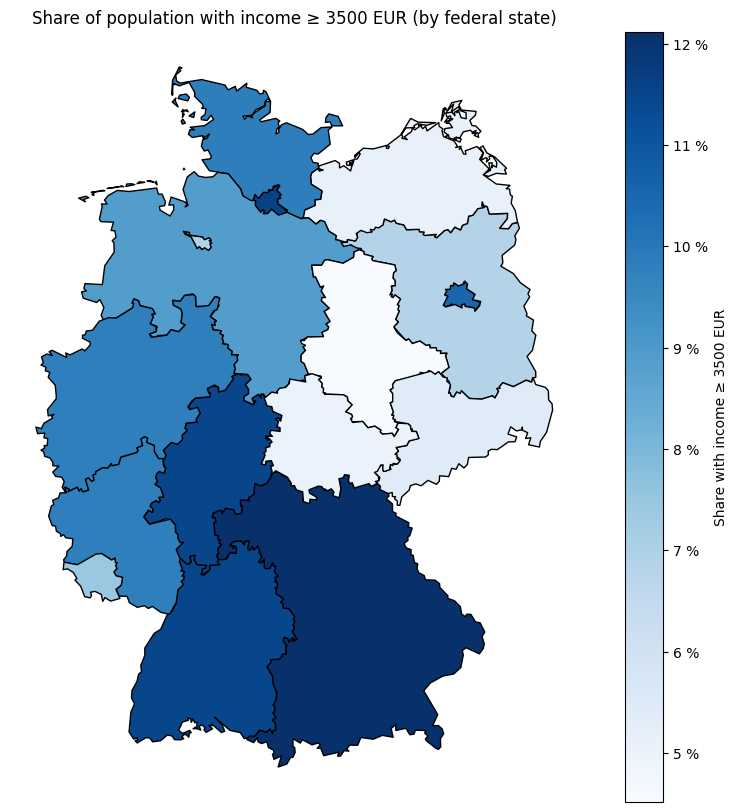

In [38]:
gdf_plot = gdf_states.merge(
    df_hi[["Bundesland", "share_hi_all"]],
    left_on="NAME_1",
    right_on="Bundesland",
    how="left"
)

fig, ax = plt.subplots(figsize=(12, 10))
gdf_plot.plot(
    column="share_hi_all",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax,
    legend_kwds={"label": "Share with income ≥ 3500 EUR", "format": "%.0f %%"}
)

ax.set_title("Share of population with income ≥ 3500 EUR (by federal state)")
ax.axis("off")
plt.show()


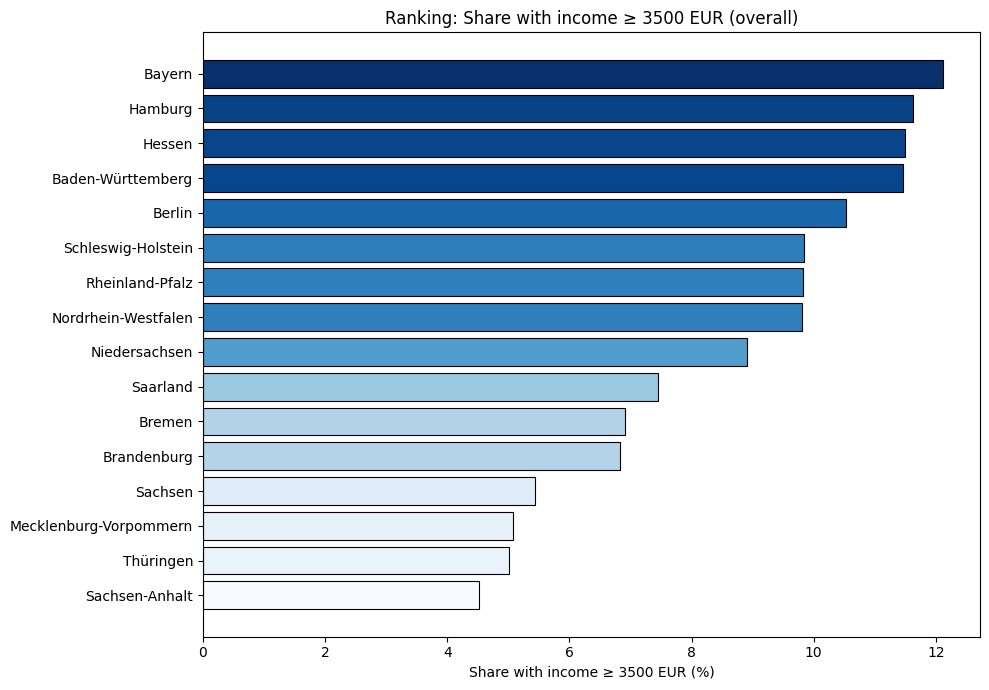

In [39]:
df_rank = df_hi[["Bundesland", "share_hi_all"]].copy()
df_rank = df_rank.sort_values("share_hi_all", ascending=True)

colors = plt.cm.Blues(
    (df_rank["share_hi_all"] - df_rank["share_hi_all"].min()) /
    (df_rank["share_hi_all"].max() - df_rank["share_hi_all"].min()))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df_rank["Bundesland"], df_rank["share_hi_all"], color=colors, edgecolor="black", linewidth=0.8)
ax.set_xlabel("Share with income ≥ 3500 EUR (%)")
ax.set_title("Ranking: Share with income ≥ 3500 EUR (overall)")

plt.tight_layout()
plt.show()


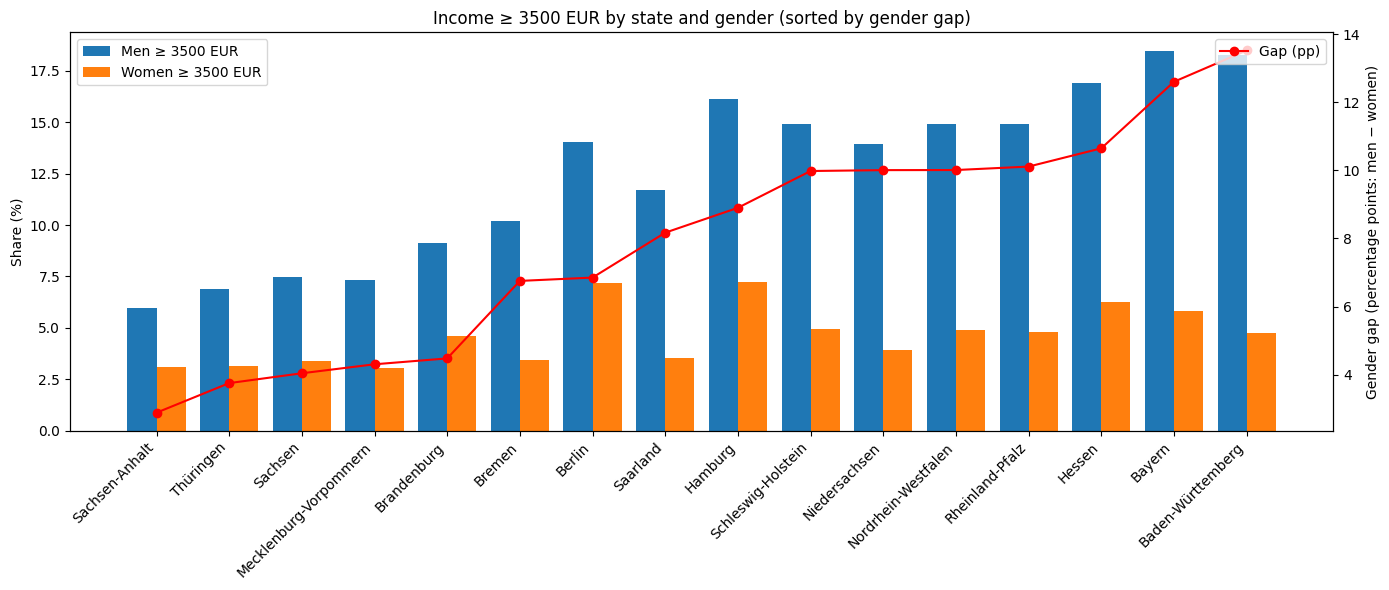

In [40]:
df_gap = df_hi[["Bundesland", "share_hi_men", "share_hi_women", "gap_hi_pp"]].copy()
df_gap = df_gap.sort_values("gap_hi_pp", ascending=True).reset_index(drop=True)

x = np.arange(len(df_gap))
bar_w = 0.40

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(x - bar_w/2, df_gap["share_hi_men"], width=bar_w, label="Men ≥ 3500 EUR")
ax1.bar(x + bar_w/2, df_gap["share_hi_women"], width=bar_w, label="Women ≥ 3500 EUR")

ax1.set_xticks(x)
ax1.set_xticklabels(df_gap["Bundesland"], rotation=45, ha="right")
ax1.set_ylabel("Share (%)")
ax1.set_title("Income ≥ 3500 EUR by state and gender (sorted by gender gap)")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, df_gap["gap_hi_pp"], color="red", marker="o", label="Gap (pp)")
ax2.set_ylabel("Gender gap (percentage points: men − women)")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


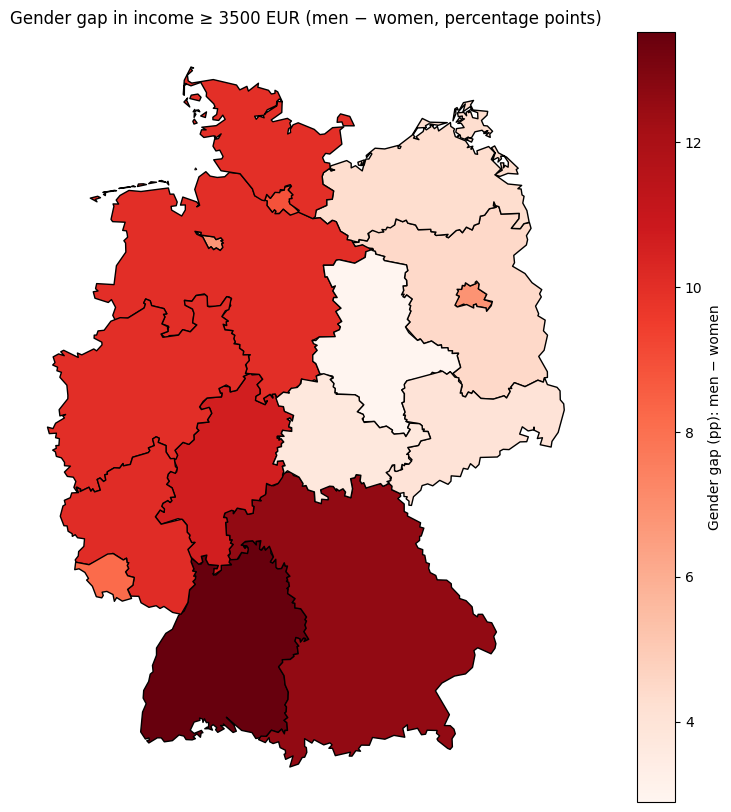

In [41]:
gdf_plot = gdf_states.merge(
    df_hi[["Bundesland", "gap_hi_pp"]],
    left_on="NAME_1",
    right_on="Bundesland",
    how="left"
)

fig, ax = plt.subplots(figsize=(12, 10))
gdf_plot.plot(
    column="gap_hi_pp",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax,
    legend_kwds={"label": "Gender gap (pp): men − women", "format": "%.0f"}
)

ax.set_title("Gender gap in income ≥ 3500 EUR (men − women, percentage points)")
ax.axis("off")
plt.show()


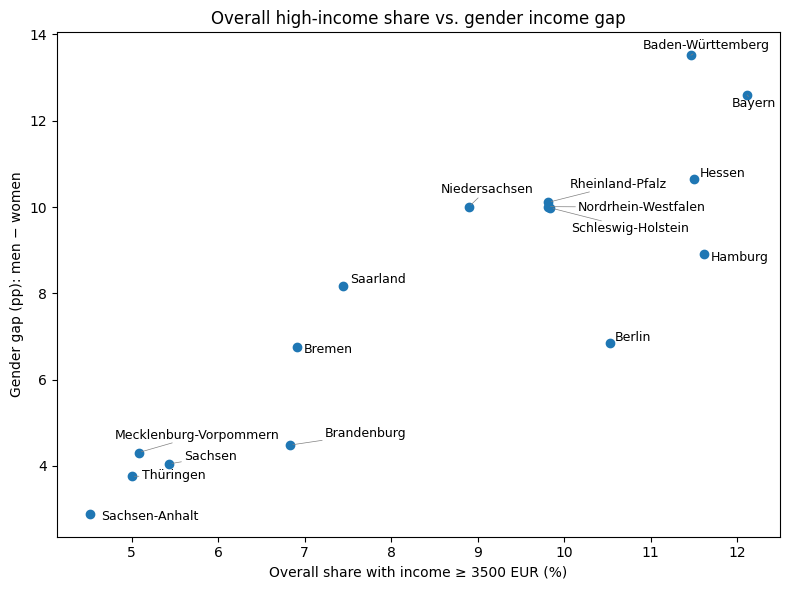

In [42]:
df_scatter = df_hi[["Bundesland", "share_hi_all", "gap_hi_pp"]].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df_scatter["share_hi_all"],
    df_scatter["gap_hi_pp"]
)

ax.set_xlabel("Overall share with income ≥ 3500 EUR (%)")
ax.set_ylabel("Gender gap (pp): men − women")
ax.set_title("Overall high-income share vs. gender income gap")

texts = []
for _, row in df_scatter.iterrows():
    texts.append(
        ax.text(
            row["share_hi_all"],
            row["gap_hi_pp"],
            row["Bundesland"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

plt.tight_layout()
plt.show()



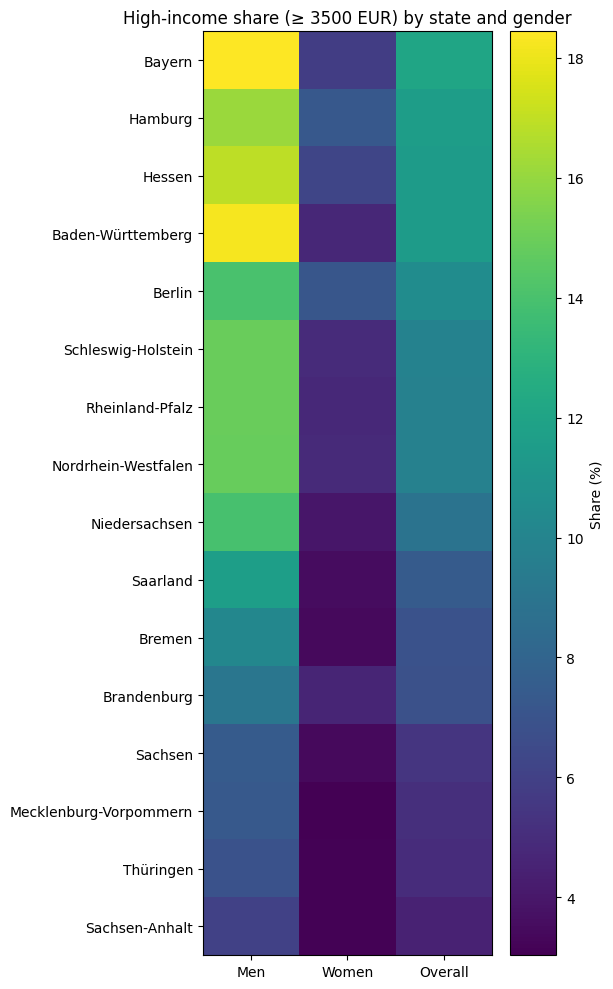

In [43]:
df_heat = df_hi.set_index("Bundesland")[["share_hi_men", "share_hi_women", "share_hi_all"]]
df_heat = df_heat.rename(columns={
    "share_hi_men": "Men",
    "share_hi_women": "Women",
    "share_hi_all": "Overall"
})

df_heat = df_heat.sort_values("Overall", ascending=False)

fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(df_heat.values, aspect="auto")

ax.set_yticks(np.arange(len(df_heat.index)))
ax.set_yticklabels(df_heat.index)
ax.set_xticks(np.arange(len(df_heat.columns)))
ax.set_xticklabels(df_heat.columns)

ax.set_title("High-income share (≥ 3500 EUR) by state and gender")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Share (%)")

plt.tight_layout()
plt.show()


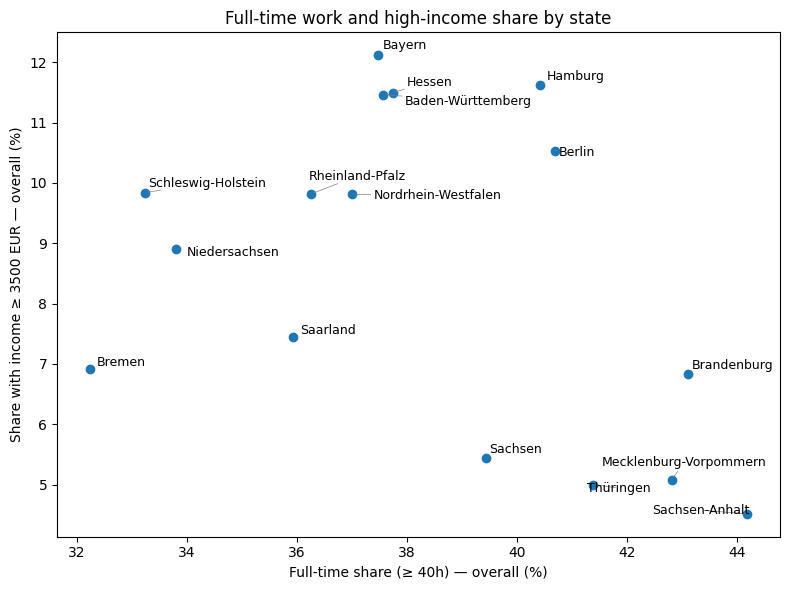

In [44]:
df_merge = df_hi.merge(df_ft[["Bundesland", "share_ft_all"]], on="Bundesland", how="inner").dropna()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df_merge["share_ft_all"],
    df_merge["share_hi_all"]
)

ax.set_xlabel("Full-time share (≥ 40h) — overall (%)")
ax.set_ylabel("Share with income ≥ 3500 EUR — overall (%)")
ax.set_title("Full-time work and high-income share by state")

texts = []
for _, row in df_merge.iterrows():
    texts.append(
        ax.text(
            row["share_ft_all"],
            row["share_hi_all"],
            row["Bundesland"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

plt.tight_layout()
plt.show()


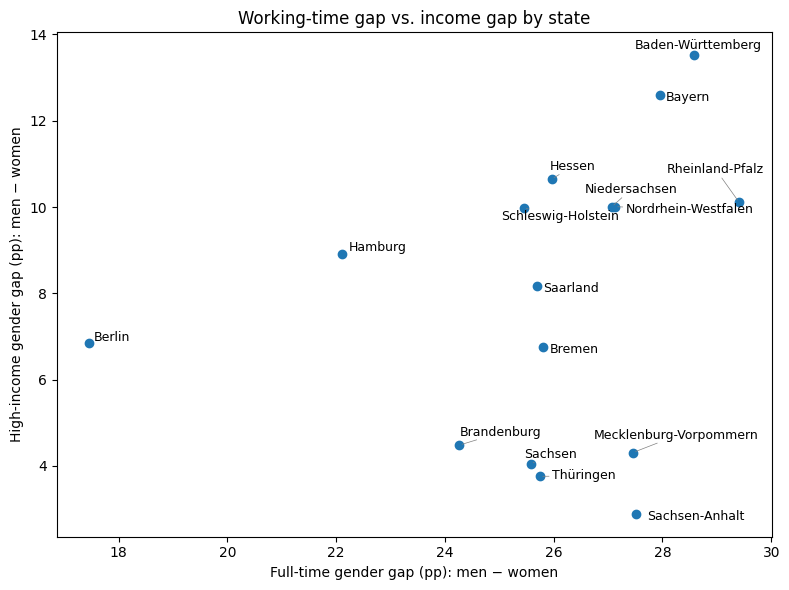

In [45]:
df_gap_merge = df_hi.merge(df_ft[["Bundesland", "gap_ft_pp"]], on="Bundesland", how="inner").dropna()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df_gap_merge["gap_ft_pp"],
    df_gap_merge["gap_hi_pp"]
)

ax.set_xlabel("Full-time gender gap (pp): men − women")
ax.set_ylabel("High-income gender gap (pp): men − women")
ax.set_title("Working-time gap vs. income gap by state")

texts = []
for _, row in df_gap_merge.iterrows():
    texts.append(
        ax.text(
            row["gap_ft_pp"],
            row["gap_hi_pp"],
            row["Bundesland"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

plt.tight_layout()
plt.show()

